# Chronos/Chronos2 visualization (one file)

This notebook helps you pick a dataset file (by index or name) and visualize:
- time series with **ground-truth anomalies**
- anomaly **score**
- **predicted anomalies** (raw + adjusted)

Works with cached scores saved by `benchmark_exp/Run_Detector_U.py` (`eval/score/uni/<MODEL>/<FILE>.npy`).


In [23]:
import os

os.chdir("/workspace/skoltech/tsfm-2026")

print(os.getcwd())

/workspace/skoltech/tsfm-2026


In [39]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()

# Paths
DATASET_DIR = PROJECT_ROOT / "Datasets" / "TSB-AD-M"  # adjust if different
FILE_LIST = PROJECT_ROOT / "Datasets" / "File_List" / "TSB-AD-M-picked.csv"
SCORE_DIR = PROJECT_ROOT / "eval" / "score" / "multi"

# Model
MODEL_NAME = "Chronos2FastPredictMean"  # e.g. Chronos2Fast / Chronos2Prob / Chronos2

# Select file by index OR set FILE_NAME directly
FILE_INDEX = 5
FILE_NAME = ""#"383_UCR_id_81_Medical_tr_1875_1st_3198.csv"  # if non-empty, takes priority


In [40]:
# Load file list
file_list = pd.read_csv(FILE_LIST)["file_name"].dropna().astype(str).tolist()

if FILE_NAME:
    filename = FILE_NAME
else:
    filename = file_list[FILE_INDEX]

print("Selected:", filename)
csv_path = DATASET_DIR / filename
print("CSV:", csv_path)

df = pd.read_csv(csv_path).dropna()
data = df.iloc[:, 0:-1].values.astype(float)
label = df["Label"].astype(int).to_numpy()

# Use the first channel for plotting by default
x = data[:, 0]
print("len:", len(x), "channels:", data.shape[1], "anomaly%:", float(label.mean()))


Selected: 024_MITDB_id_6_Medical_tr_50000_1st_58118.csv
CSV: /workspace/skoltech/tsfm-2026/Datasets/TSB-AD-M/024_MITDB_id_6_Medical_tr_50000_1st_58118.csv
len: 200000 channels: 2 anomaly%: 0.001765


In [41]:
# Load cached score (preferred)
score_path = SCORE_DIR / MODEL_NAME / (Path(filename).stem + ".npy")
print("Score path:", score_path)

if score_path.exists():
    score = np.load(score_path)
    print("Loaded cached score", score.shape)
else:
    # Optional: compute score on the fly (can be slow)
    from TSB_AD.model_wrapper import run_Unsupervise_AD
    from TSB_AD.HP_list import Optimal_Uni_algo_HP_dict

    hp = dict(Optimal_Uni_algo_HP_dict.get(MODEL_NAME, {}))
    # Force CUDA if the model supports `device`
    hp.setdefault("device", "cuda")

    score = run_Unsupervise_AD(MODEL_NAME, data, **hp)
    score = np.asarray(score).ravel()
    print("Computed score", score.shape)


Score path: /workspace/skoltech/tsfm-2026/eval/score/multi/Chronos2FastPredictMean/024_MITDB_id_6_Medical_tr_50000_1st_58118.npy
Loaded cached score (200000,)


## Thresholding (robust)

Two useful modes for visualization:

- `threshold_mode = "label_opt"`: choose the threshold that maximizes point-wise F1 using ground-truth labels (good for debugging / plots, but it **uses labels**).
- `threshold_mode = "quantile"`: choose a fixed score quantile (does not use labels; ensures some predicted anomalies).


In [42]:
from sklearn.metrics import precision_recall_curve
from TSB_AD.evaluation.basic_metrics import basic_metricor

threshold_mode = "label_opt"  # label_opt | quantile
quantile = 0.995

if threshold_mode == "label_opt":
    precision, recall, thresholds = precision_recall_curve(label, score)
    f1 = 2 * (precision * recall) / (precision + recall + 1e-12)
    # `thresholds` has length N-1 vs precision/recall length N
    best_i = int(np.nanargmax(f1[:-1]))
    threshold = float(thresholds[best_i])
elif threshold_mode == "quantile":
    threshold = float(np.quantile(score, quantile))
else:
    raise ValueError("Unknown threshold_mode")

pred = (score > threshold).astype(int)

# "Adjusted" preds (range-aware) used in TSB-AD evaluation
grader = basic_metricor()
pred_adjusted = grader._adjust_predicts(score, label, pred=pred)

print("threshold:", threshold)
print("pred positives:", int(pred.sum()), "adjusted positives:", int(np.sum(pred_adjusted)))


threshold: 0.9999211430549622
pred positives: 2 adjusted positives: 353


## Summary (why the score looks like this)

Below we print:
- confusion matrix for `pred` and `pred_adjusted`
- a few scalar metrics on this file

If you see **"0 predicted anomalies"**, that means the chosen threshold is too high for this series (even if ROC-AUC is high).


In [43]:
from sklearn.metrics import confusion_matrix, roc_auc_score, f1_score, precision_score, recall_score
from TSB_AD.evaluation.basic_metrics import basic_metricor

def _confmat(y_true, y_pred):
    # rows=true [0,1], cols=pred [0,1]
    return confusion_matrix(y_true, y_pred, labels=[0, 1])

cm_raw = _confmat(label, pred)
cm_adj = _confmat(label, pred_adjusted.astype(int))

print("Confusion matrix (raw pred):")
print(cm_raw)
print("TN FP / FN TP:")
print(cm_raw[0,0], cm_raw[0,1], "/", cm_raw[1,0], cm_raw[1,1])

print("\nConfusion matrix (adjusted pred):")
print(cm_adj)
print("TN FP / FN TP:")
print(cm_adj[0,0], cm_adj[0,1], "/", cm_adj[1,0], cm_adj[1,1])

# Scalar metrics (note: ROC-AUC uses continuous score and ignores the threshold)
try:
    auc = float(roc_auc_score(label, score))
except Exception:
    auc = float('nan')

prec = float(precision_score(label, pred, zero_division=0))
rec = float(recall_score(label, pred, zero_division=0))
f1 = float(f1_score(label, pred, zero_division=0))

prec_adj = float(precision_score(label, pred_adjusted.astype(int), zero_division=0))
rec_adj = float(recall_score(label, pred_adjusted.astype(int), zero_division=0))
f1_adj = float(f1_score(label, pred_adjusted.astype(int), zero_division=0))

grader = basic_metricor()
ece = grader.metric_ECE(label, score, n_bins=10, clip=True, from_raw_score=True)

print("\nFile metrics:")
print(f"ROC-AUC (score): {auc:.4f}")
print(f"F1 (raw pred): {f1:.4f} | Precision {prec:.4f} | Recall {rec:.4f}")
print(f"F1 (adjusted pred): {f1_adj:.4f} | Precision {prec_adj:.4f} | Recall {rec_adj:.4f}")
print(f"ECE (score, scaled to [0,1]): {float(ece):.4f}")


Confusion matrix (raw pred):
[[199647      0]
 [   351      2]]
TN FP / FN TP:
199647 0 / 351 2

Confusion matrix (adjusted pred):
[[199647      0]
 [     0    353]]
TN FP / FN TP:
199647 0 / 0 353

File metrics:
ROC-AUC (score): 0.6733
F1 (raw pred): 0.0113 | Precision 1.0000 | Recall 0.0057
F1 (adjusted pred): 1.0000 | Precision 1.0000 | Recall 1.0000
ECE (score, scaled to [0,1]): 0.0013


## Plots

1) series + ground-truth anomalies (shaded)

2) anomaly score + threshold

3) predicted anomalies (raw + adjusted)


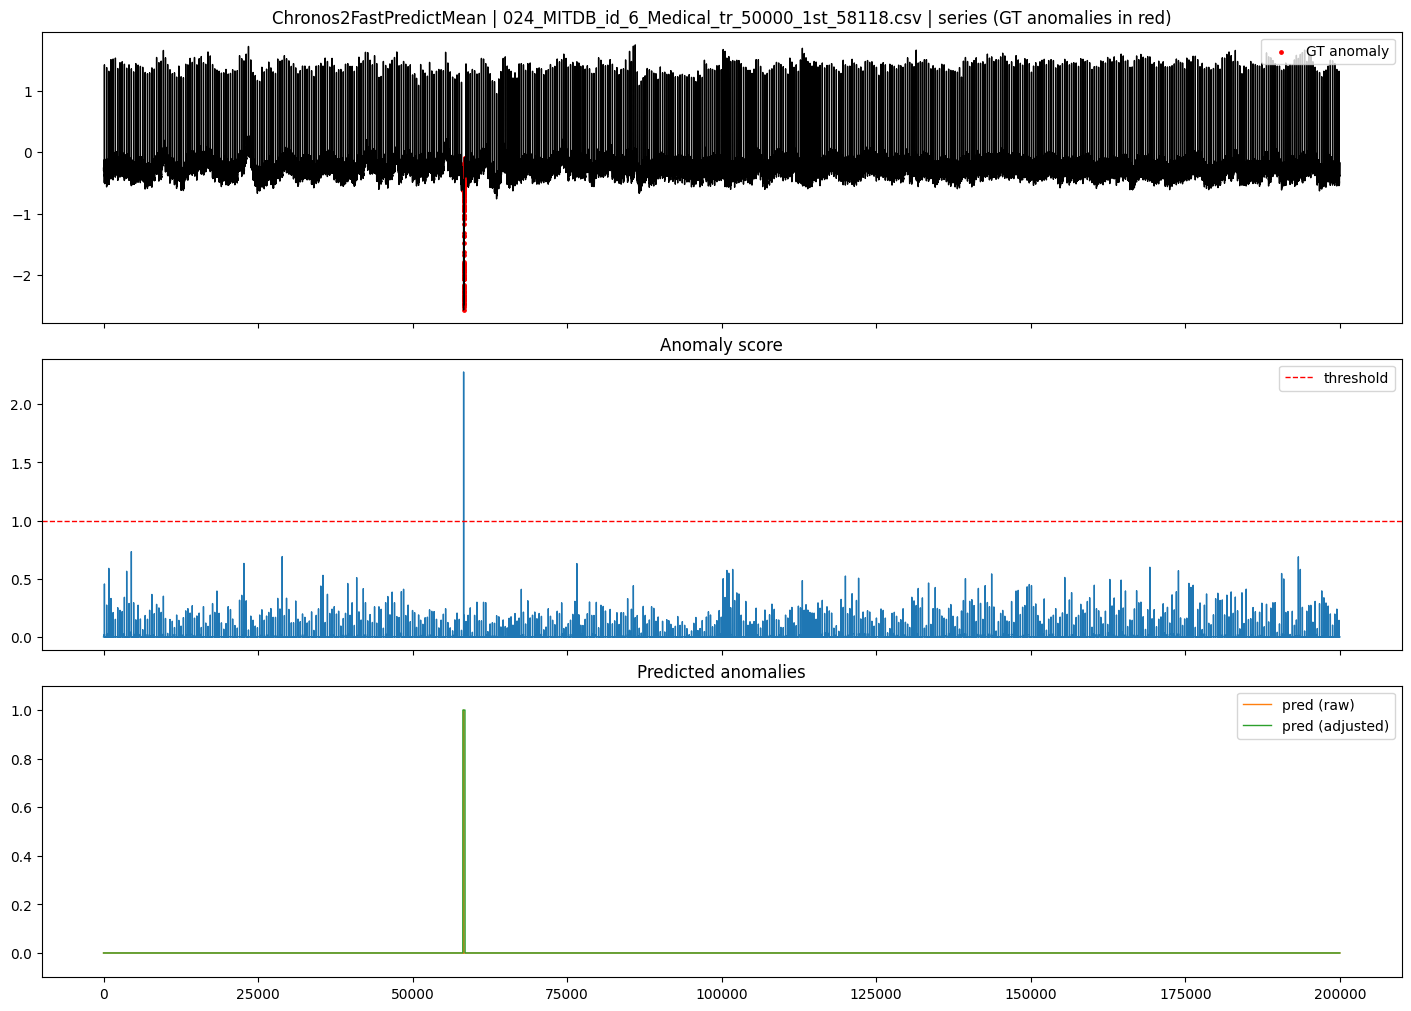

In [44]:
t = np.arange(len(x))
anomaly_idx = np.where(label > 0)[0]

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True, constrained_layout=True)

# 1) series
ax = axes[0]
ax.plot(t, x, color="black", linewidth=1)
if anomaly_idx.size:
    ax.scatter(anomaly_idx, x[anomaly_idx], color="red", s=6, label="GT anomaly")
ax.set_title(f"{MODEL_NAME} | {filename} | series (GT anomalies in red)")
ax.legend(loc="upper right")

# 2) score
ax = axes[1]
ax.plot(t, score, color="tab:blue", linewidth=1)
ax.axhline(threshold, color="red", linestyle="--", linewidth=1, label="threshold")
ax.set_title("Anomaly score")
ax.legend(loc="upper right")

# 3) predicted anomalies
ax = axes[2]
ax.plot(t, pred, color="tab:orange", linewidth=1, label="pred (raw)")
ax.plot(t, pred_adjusted.astype(int), color="tab:green", linewidth=1, label="pred (adjusted)")
ax.set_ylim(-0.1, 1.1)
ax.set_title("Predicted anomalies")
ax.legend(loc="upper right")

plt.show()
